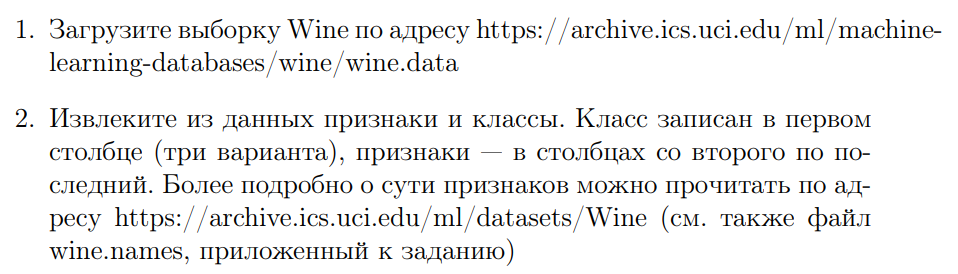

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('wine.data.txt', header=None)

# Извлекаем классы (первый столбец)
y = data.iloc[:, 0].values

# Извлекаем признаки (со 2-го столбца по последний)
X = data.iloc[:, 1:].values

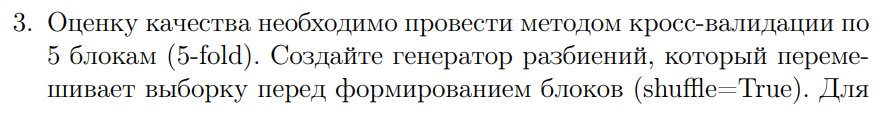
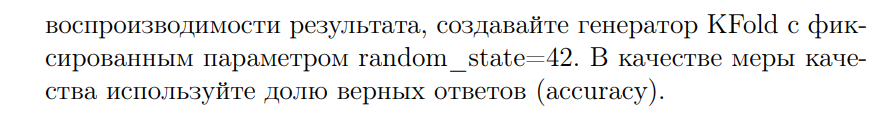

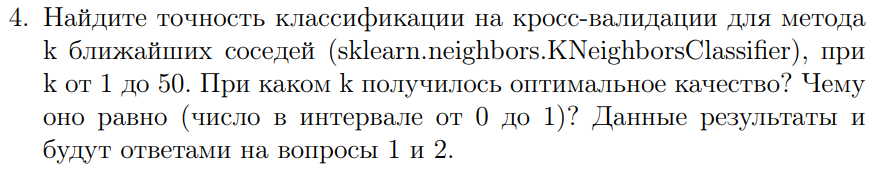

In [11]:
# Создаём генератор разбиений KFold (5-fold cross-validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Ищем оптимальное k от 1 до 50
k_values = range(1, 51)
accuracies_without_scaling = []

print('Вычисление точности для k от 1 до 50 (без масштабирования)...')
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    # Оцениваем качество методом кросс-валидации
    scores = cross_val_score(clf, X, y, cv=kfold, scoring='accuracy')
    mean_accuracy = scores.mean()
    accuracies_without_scaling.append(mean_accuracy)

# Находим оптимальное k
optimal_k_1 = list(k_values)[np.argmax(accuracies_without_scaling)]
optimal_accuracy_1 = max(accuracies_without_scaling)

print(f'\nОптимальное значение k (без масштабирования): {optimal_k_1}')
print(f'Оптимальная точность (без масштабирования): {optimal_accuracy_1:.2f}')

Вычисление точности для k от 1 до 50 (без масштабирования)...

Оптимальное значение k (без масштабирования): 1
Оптимальная точность (без масштабирования): 0.73


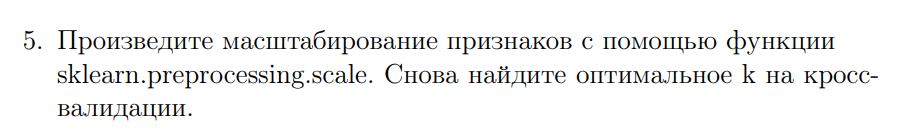

In [ ]:
# Масштабируем признаки
X_scaled = scale(X)

# Проверяем результат масштабирования
print('\nПроверка масштабирования:')
print(f'  Среднее значение (должно быть близко к 0): {X_scaled.mean():.6f}')
print(f'  Стандартное отклонение (должно быть близко к 1): {X_scaled.std():.6f}')

# Ищем оптимальное k на масштабированных данных
accuracies_with_scaling = []

print('\nВычисление точности для k от 1 до 50 (с масштабированием)...')
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_scaled, y, cv=kfold, scoring='accuracy')
    mean_accuracy = scores.mean()
    accuracies_with_scaling.append(mean_accuracy)

# Находим оптимальное k
optimal_k_2 = list(k_values)[np.argmax(accuracies_with_scaling)]
optimal_accuracy_2 = max(accuracies_with_scaling)

print(f'\nВОПРОС 3: Оптимальное значение k (с масштабированием): {optimal_k_2}')
print(f'ВОПРОС 4: Оптимальная точность (с масштабированием): {optimal_accuracy_2:.2f}')


Проверка масштабирования:
  Среднее значение (должно быть близко к 0): -0.000000
  Стандартное отклонение (должно быть близко к 1): 1.000000

Вычисление точности для k от 1 до 50 (с масштабированием)...

ВОПРОС 3: Оптимальное значение k (с масштабированием): 29
ВОПРОС 4: Оптимальная точность (с масштабированием): 0.98


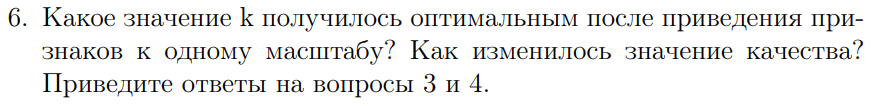

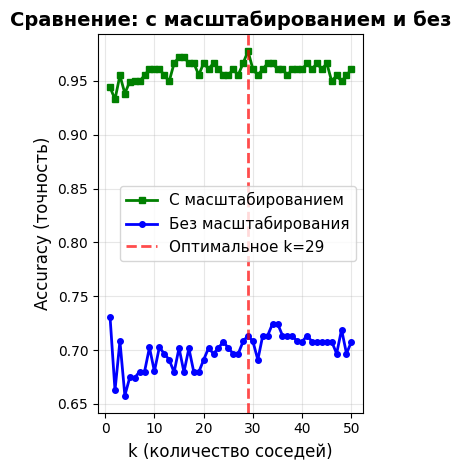


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

БЕЗ МАСШТАБИРОВАНИЯ:
  ВОПРОС 1: Оптимальное k = 1
  ВОПРОС 2: Точность = 0.73

С МАСШТАБИРОВАНИЕМ:
  ВОПРОС 3: Оптимальное k = 29
  ВОПРОС 4: Точность = 0.98

Изменение точности: +0.25
  → Качество УЛУЧШИЛОСЬ после масштабирования на 0.25


In [12]:
# Визуализация сравнения
plt.subplot(1, 2, 2)
plt.plot(list(k_values), accuracies_with_scaling, 'g-', marker='s', markersize=4, linewidth=2, label='С масштабированием')
plt.plot(list(k_values), accuracies_without_scaling, 'b-', marker='o', markersize=4, linewidth=2, label='Без масштабирования')
plt.axvline(x=optimal_k_2, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Оптимальное k={optimal_k_2}')
plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('Accuracy (точность)', fontsize=12)
plt.title('Сравнение: с масштабированием и без', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Изменение качества
accuracy_change = optimal_accuracy_2 - optimal_accuracy_1

print(f'\n{"="*70}')
print(f'ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
print(f'{"="*70}')
print(f'\nБЕЗ МАСШТАБИРОВАНИЯ:')
print(f'  ВОПРОС 1: Оптимальное k = {optimal_k_1}')
print(f'  ВОПРОС 2: Точность = {optimal_accuracy_1:.2f}')

print(f'\nС МАСШТАБИРОВАНИЕМ:')
print(f'  ВОПРОС 3: Оптимальное k = {optimal_k_2}')
print(f'  ВОПРОС 4: Точность = {optimal_accuracy_2:.2f}')

print(f'\nИзменение точности: {accuracy_change:+.2f}')
if accuracy_change > 0:
    print(f'  → Качество УЛУЧШИЛОСЬ после масштабирования на {accuracy_change:.2f}')
elif accuracy_change < 0:
    print(f'  → Качество УХУДШИЛОСЬ после масштабирования на {abs(accuracy_change):.2f}')
else:
    print(f'  → Качество НЕ ИЗМЕНИЛОСЬ')